# SentiSense — Analysis, Modeling & Explainability

The post-ingestion **last stages** (features → clustering → baselines → LSTM tuning →
holdout → backtest) with **visualizations** and **explainability**. Reuses the
`sentisense` package — no logic is duplicated here; this notebook is the *viz/results*
surface over the same functions the CLI pipeline runs.

**Hard invariants** (enforced inside the package): cutoff `<= 2023-10-07`, train-only
scaling/PCA, chronological / TimeSeriesSplit validation, sacred held-out test.

## Prerequisites
```bash
uv sync --extra ml --extra embed --extra finance --extra notebook   # at repo root
# .env has the DB URL + local LLM backend
```
Heavy explainability deps (shap, umap, seaborn) are also lazy-installed in §0 if missing.

## Sections
0. Setup  · 1. Coverage & EDA  · 2. Features  · 3. Embeddings & clustering  ·
4. Baselines + SHAP/permutation explainability  · 5. LSTM tuning (Optuna viz)  ·
6. Holdout: ROC/PR, calibration, threshold, confusion  · 7. Backtest (equity / Sharpe / drawdown)  ·
8. Verdict


## 0. Setup

In [1]:
# Lazy-install analysis/explainability extras if absent (heavy; not in base env).
import importlib, subprocess, sys
for pkg, imp in [("shap", "shap"), ("umap-learn", "umap"), ("seaborn", "seaborn")]:
    if importlib.util.find_spec(imp) is None:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg], check=False)



[notice] A new release of pip is available: 26.1 -> 26.1.2
[notice] To update, run: python3 -m pip install --upgrade pip

[notice] A new release of pip is available: 26.1 -> 26.1.2
[notice] To update, run: python3 -m pip install --upgrade pip


In [2]:
from __future__ import annotations
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import text

import sentisense  # loads .env
from sentisense.db import get_engine, get_connection_url
from sentisense.constants import CUTOFF_DATE

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 40)
engine = get_engine()
print("DB:", get_connection_url().rsplit("@", 1)[-1])
print("Cutoff:", CUTOFF_DATE)


def feat_family(col: str) -> str:
    """Bucket a feature column into its signal source (for grouped explainability)."""
    if col.startswith(("mean_", "ix_")) or col == "n_headlines":
        return "news"
    if col.startswith(("SP500_", "VIX_", "Brent_", "USDILS_", "VTA35_", "Market_", "FX_")):
        return "cross_asset"
    if col.startswith(("TA125_", "DoW_")):
        return "technical"
    return "other"


DB: localhost:5432/sentisense
Cutoff: 2023-10-07


## 1. Coverage & EDA
Corpus reach, per-model scored breakdown, monthly volume.

,model_name,validated,total
0,mistral-small-4,2348726,2348949
1,mistral-small:latest,52640,61645


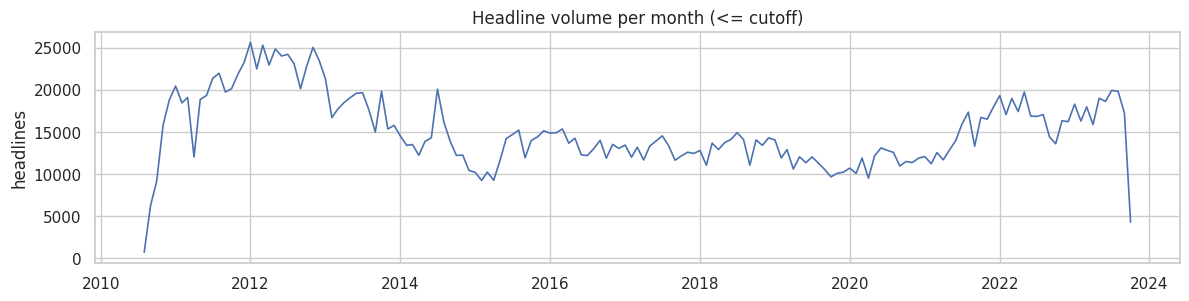

In [3]:
models = pd.read_sql(text('''
    SELECT nv.model_name,
           COUNT(*) FILTER (WHERE nv.validation_passed) AS validated,
           COUNT(*) AS total
    FROM nlp_vectors nv JOIN raw_headlines rh ON rh.id = nv.headline_id AND rh.date <= :c
    GROUP BY nv.model_name ORDER BY validated DESC
'''), engine, params={"c": CUTOFF_DATE})
display(models)

monthly = pd.read_sql(text('''
    SELECT to_char(date_trunc('month', date), 'YYYY-MM') AS month, COUNT(*) AS raw
    FROM raw_headlines WHERE date <= :c GROUP BY 1 ORDER BY 1
'''), engine, params={"c": CUTOFF_DATE})
fig, ax = plt.subplots(figsize=(14, 3))
ax.plot(pd.to_datetime(monthly["month"]), monthly["raw"], lw=1.2)
ax.set_title("Headline volume per month (<= cutoff)"); ax.set_ylabel("headlines"); plt.show()


## 2. Features
Build the leak-safe daily frames. Inspect feature groups + correlations + target balance over time.

In [4]:
from sentisense.features import build_datasets
mt, ml = build_datasets(engine)   # daily-mean (tree shape), per-source (LSTM shape)
print("mt (daily-mean):", mt.shape, "| ml (per-source):", ml.shape)
print("target +rate:", f"{mt['Target'].mean():.3f}")

fam_counts = pd.Series([feat_family(c) for c in mt.columns if c != "Target"]).value_counts()
print("feature families:", fam_counts.to_dict())


2026-06-20 04:45:56.831 | INFO     | sentisense.features.dataset:_load_raw_scores:78 - Loaded 2,401,366 validated headlines (<= 2023-10-07), 59 sources, models=['mistral-small-4', 'mistral-small:latest']
2026-06-20 04:45:59.749 | INFO     | sentisense.features.dataset:build_datasets:403 - Datasets built (<= 2023-10-07): mt=(1914, 64), ml=(1914, 160)
2026-06-20 04:45:59.749 | INFO     | sentisense.features.dataset:build_datasets:404 -   trading-day rows: mt=1,914, ml=1,914  (LSTM-viability bar ~750)


mt (daily-mean): (1914, 64) | ml (per-source): (1914, 160)
target +rate: 0.531
feature families: {'cross_asset': 31, 'technical': 18, 'news': 14}


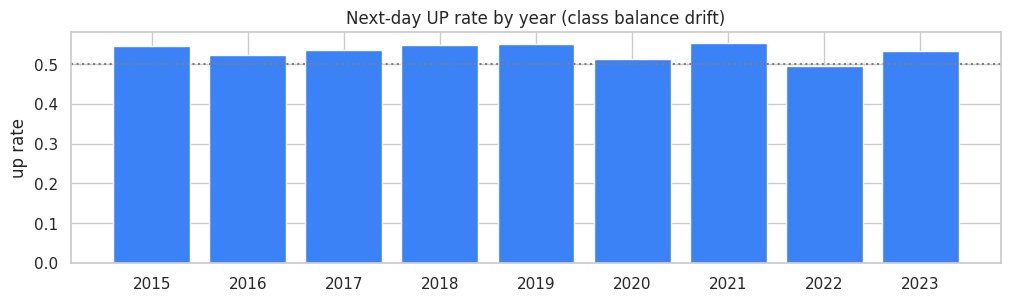

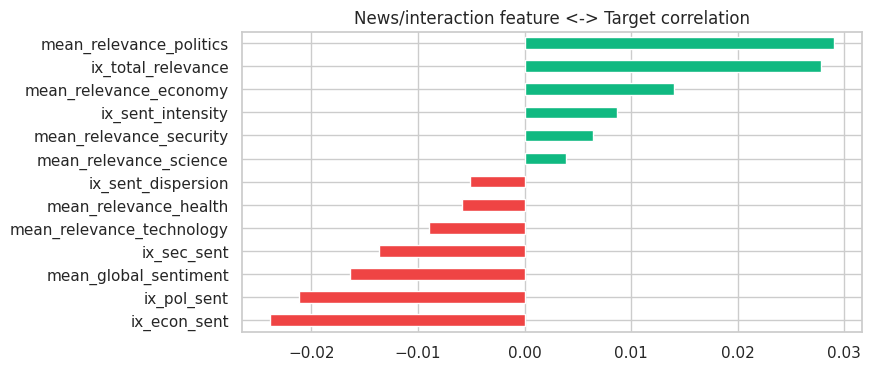

In [5]:
# Target rate by year — is the up/down balance stable, or regime-drifting?
yr = mt.assign(year=mt.index.year).groupby("year")["Target"].agg(["mean", "size"])
fig, ax = plt.subplots(figsize=(12, 3))
ax.bar(yr.index.astype(str), yr["mean"], color="#3b82f6"); ax.axhline(0.5, ls=":", c="gray")
ax.set_title("Next-day UP rate by year (class balance drift)"); ax.set_ylabel("up rate"); plt.show()

# Correlation of the news + interaction features with the target.
news_ix = [c for c in mt.columns if c.startswith(("mean_", "ix_"))]
corr = mt[news_ix + ["Target"]].corr()["Target"].drop("Target").sort_values()
fig, ax = plt.subplots(figsize=(8, max(3, 0.3 * len(corr))))
corr.plot.barh(ax=ax, color=np.where(corr > 0, "#10b981", "#ef4444"))
ax.set_title("News/interaction feature <-> Target correlation"); plt.show()


## 3. Embeddings & narrative clustering
2-D map of daily e5 centroids colored by next-day direction; dominant-cluster-ratio over time.

cached embeddings: 2401552 dim: 768


I0000 00:00:1781930810.214264 1945018 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1781930810.454663 1945018 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1781930811.375233 1945018 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use n

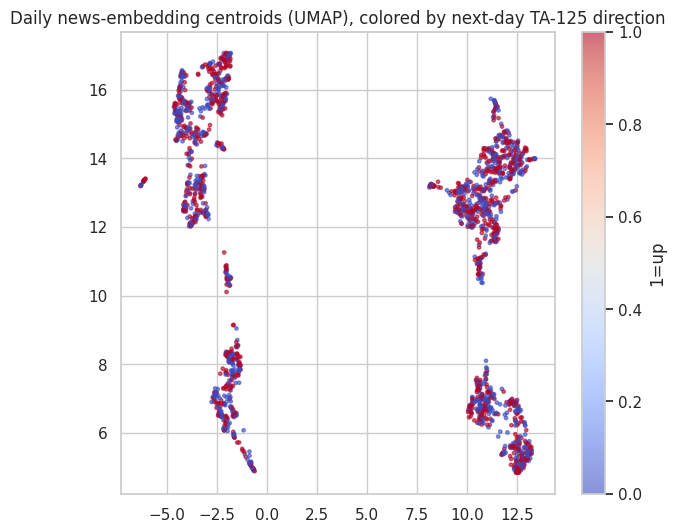

In [6]:
from sentisense.embed import load_embeddings
meta, vecs = load_embeddings(engine)
print("cached embeddings:", len(meta), "dim:", (vecs.shape[1] if vecs.size else 0))
if vecs.size:
    # daily centroid -> UMAP 2-D, colored by that day's next-day direction
    cen = pd.DataFrame(vecs, index=pd.to_datetime(meta["date"].values)).groupby(level=0).mean()
    common = cen.index.intersection(mt.index)
    import umap
    emb2d = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=0).fit_transform(cen.loc[common].values)
    lab = mt.loc[common, "Target"].values
    fig, ax = plt.subplots(figsize=(7, 6))
    sc = ax.scatter(emb2d[:, 0], emb2d[:, 1], c=lab, cmap="coolwarm", s=6, alpha=0.6)
    ax.set_title("Daily news-embedding centroids (UMAP), colored by next-day TA-125 direction")
    plt.colorbar(sc, label="1=up"); plt.show()
else:
    print("No embeddings yet — run the embed stage first.")


2026-06-20 04:53:11.330 | INFO     | sentisense.cluster.narrative:build_narrative_features:87 - Narrative features built for 4,788 days (k=8, refit_every=30).


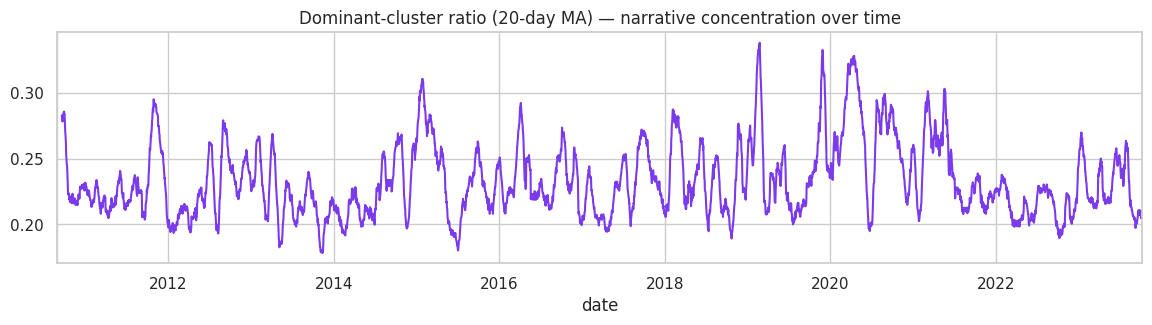

,dominant_cluster_ratio,cluster_entropy,narrative_n_headlines
count,4787.000000,4787.000000,4788.000000
mean,0.233157,0.940130,501.577277
std,0.043491,0.035378,194.632625
min,0.133758,0.724007,3.000000
25%,0.202653,0.922277,351.000000
50%,0.225000,0.947704,487.000000
75%,0.255157,0.965685,626.000000
max,0.666667,0.998474,1207.000000


In [7]:
from sentisense.cluster import build_narrative_features
nf = build_narrative_features(engine)
if nf is not None and not nf.empty:
    fig, ax = plt.subplots(figsize=(14, 3))
    nf["dominant_cluster_ratio"].rolling(20).mean().plot(ax=ax, color="#7c3aed")
    ax.set_title("Dominant-cluster ratio (20-day MA) — narrative concentration over time"); plt.show()
    display(nf.describe())
else:
    print("No narrative features — run the embed stage first.")


## 4. Baselines + explainability
Naive (majority/persistence) + XGBoost on TimeSeriesSplit, then **SHAP** + **permutation
importance** on the tree to see *which feature families actually drive it* — news vs
cross-asset vs technicals. This is the honest "does the news signal earn its place?" check.

In [8]:
from sentisense.models.baselines import run_baselines
res = run_baselines(mt)
display(pd.DataFrame(res).T)


2026-06-20 04:53:12.554 | INFO     | sentisense.models.baselines:run_baselines:95 - Phase 5 baselines:
2026-06-20 04:53:12.555 | INFO     | sentisense.models.baselines:run_baselines:97 -   MajorityClass    acc=0.4913 balacc=0.5000 f1=0.3294 auc=0.5000 mcc=0.0000
2026-06-20 04:53:12.556 | INFO     | sentisense.models.baselines:run_baselines:97 -   Persistence      acc=0.5087 balacc=0.5086 f1=0.5086 auc=0.5086 mcc=0.0172
2026-06-20 04:53:12.556 | INFO     | sentisense.models.baselines:run_baselines:97 -   XGBoost_TSCV     acc=0.5304 balacc=0.5260 f1=0.5227 auc=0.5157 mcc=0.0530


,accuracy,balanced_accuracy,f1,mcc,roc_auc
MajorityClass,0.491289,0.500000,0.329439,0.000000,0.500000
Persistence,0.508711,0.508622,0.508615,0.017243,0.508622
XGBoost_TSCV,0.530408,0.525955,0.522708,0.053012,0.515716


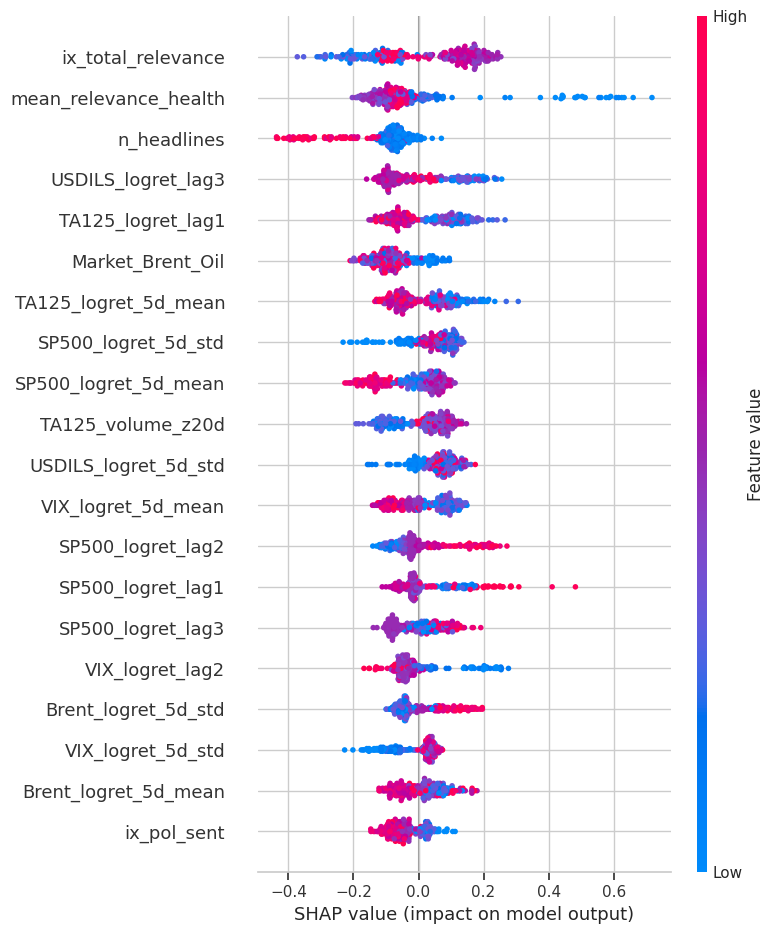

In [9]:
# Fit one XGBoost on a chronological train slice for explainability.
# (Trees need no scaling, and SHAP wants NAMED features — so we slice mt directly
#  rather than chronological_split, which returns scaled, unnamed arrays.)
import xgboost as xgb
y = mt["Target"].values.astype(int); X = mt.drop(columns=["Target"])
n = len(mt); ntr = int(n * 0.7); nva = int(n * 0.15)
Xtr, ytr = X.iloc[:ntr], y[:ntr]
Xte, yte = X.iloc[ntr + nva:], y[ntr + nva:]
pos = max(int(ytr.sum()), 1); neg = max(len(ytr) - int(ytr.sum()), 1)
clf = xgb.XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.03,
                        subsample=0.8, colsample_bytree=0.8, scale_pos_weight=neg / pos,
                        eval_metric="logloss", random_state=42, verbosity=0)
clf.fit(Xtr, ytr)

import shap
expl = shap.TreeExplainer(clf)
sv = expl.shap_values(Xte)
shap.summary_plot(sv, Xte, max_display=20, show=True)


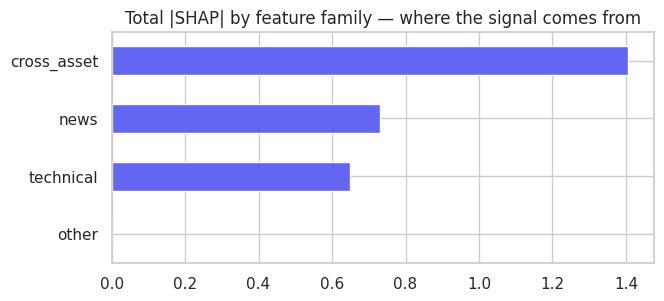

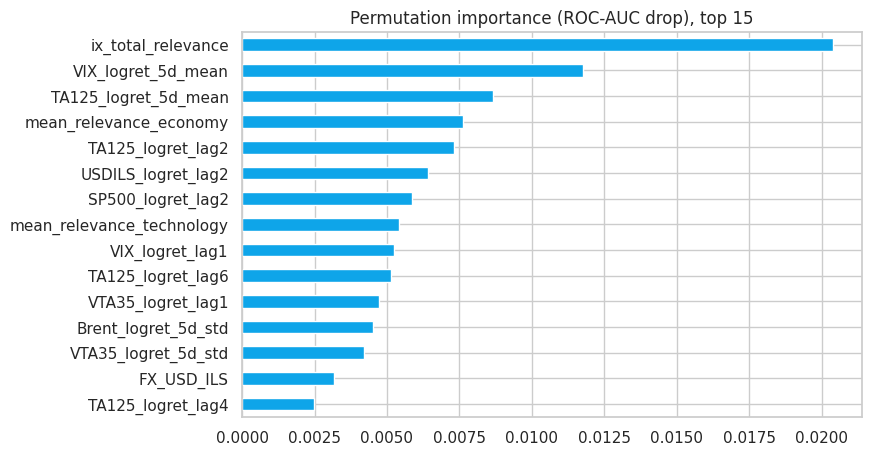

In [10]:
# Aggregate SHAP by feature FAMILY -> which signal source matters most.
absmean = np.abs(sv).mean(axis=0)
fam = {"news": 0.0, "cross_asset": 0.0, "technical": 0.0, "other": 0.0}
for col, v in zip(Xte.columns, absmean):
    fam[feat_family(col)] += v
fam = pd.Series(fam).sort_values()
fig, ax = plt.subplots(figsize=(7, 3)); fam.plot.barh(ax=ax, color="#6366f1")
ax.set_title("Total |SHAP| by feature family — where the signal comes from"); plt.show()

from sklearn.inspection import permutation_importance
pi = permutation_importance(clf, Xte, yte, n_repeats=10, random_state=42, scoring="roc_auc")
imp = pd.Series(pi.importances_mean, index=Xte.columns).sort_values(ascending=False).head(15)
fig, ax = plt.subplots(figsize=(8, 5)); imp[::-1].plot.barh(ax=ax, color="#0ea5e9")
ax.set_title("Permutation importance (ROC-AUC drop), top 15"); plt.show()


## 5. LSTM tuning — Optuna visualizations
Loads the persisted studies (score-LSTM + embedding-LSTM) from the project DB. If none
exist yet, runs a SHORT demo search so the plots render. The full HPO is the long
headless `tune` stage.

In [11]:
import os
import optuna
from sentisense.hpo.optuna_lstm import STUDY_SCORES, has_completed_trials
storage = get_connection_url()


def load_or_none(name):
    try:
        s = optuna.load_study(study_name=name, storage=storage)
        return s if has_completed_trials(s) else None
    except Exception:
        return None


study = load_or_none(STUDY_SCORES)
if study is None:
    print("No completed score-LSTM study found — running a SHORT demo (5 trials)…")
    from sentisense.hpo import run_hpo
    os.environ["SENTISENSE_OPTUNA_TRIALS"] = "5"
    study = run_hpo(ml, n_trials=5, study_name="demo_scores")
print("best value:", round(study.best_value, 4))
print("best params:", study.best_params)


best value: 0.5364
best params: {'window': 30, 'units': 48, 'n_layers': 2, 'bidirectional': False, 'd_dense': 64, 'dropout': 0.25517224758534385, 'recurrent_dropout': 0.2493707690422629, 'weight_decay': 0.0036767728790750515, 'grad_clip': 5.0, 'dense_act': 'tanh', 'pooling': 'last', 'lr': 0.004254451051730454, 'batch_size': 32}


/tmp/ipykernel_1945018/2916198123.py:2: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  plot_optimization_history(study); plt.title("Optuna optimization history (val ROC-AUC)"); plt.show()


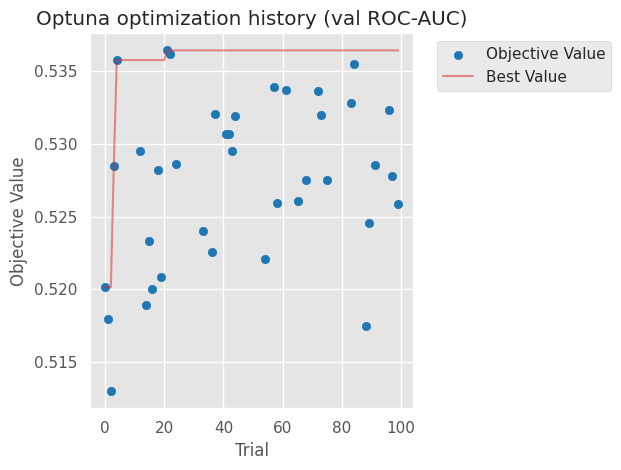

/tmp/ipykernel_1945018/2916198123.py:3: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  plot_param_importances(study); plt.title("Hyperparameter importances"); plt.show()


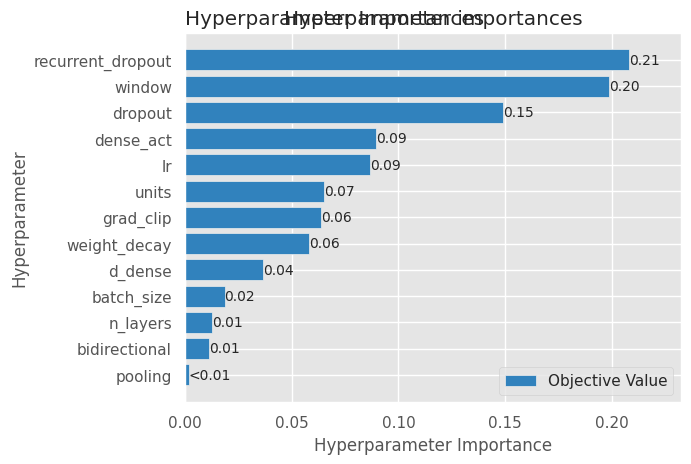

In [12]:
from optuna.visualization.matplotlib import plot_optimization_history, plot_param_importances
plot_optimization_history(study); plt.title("Optuna optimization history (val ROC-AUC)"); plt.show()
plot_param_importances(study); plt.title("Hyperparameter importances"); plt.show()


## 6. Holdout evaluation + explainability
Sacred-test metrics for the score-LSTM (calibrated + threshold-tuned), ROC, a
**reliability (calibration) diagram**, and the confusion matrix.

In [13]:
from sentisense.hpo import final_holdout_eval
summary_s, proba_s, labels_s = final_holdout_eval(ml, study.best_params, n_seeds=2)
display(pd.DataFrame(summary_s).T)


2026-06-20 04:53:17.504 | INFO     | sentisense.models.train:train_model:109 - Early stopping at epoch 16 (lstm_final_s42).
2026-06-20 04:53:19.466 | INFO     | sentisense.models.train:train_model:109 - Early stopping at epoch 20 (lstm_final_s123).
2026-06-20 04:53:19.658 | INFO     | sentisense.hpo.optuna_lstm:final_holdout_eval:298 - Phase 7 holdout (mean±std over 2 seeds):
2026-06-20 04:53:19.658 | INFO     | sentisense.hpo.optuna_lstm:final_holdout_eval:300 -   accuracy@0.5           0.4961 ± 0.0097
2026-06-20 04:53:19.659 | INFO     | sentisense.hpo.optuna_lstm:final_holdout_eval:300 -   balanced_accuracy@0.5  0.4961 ± 0.0098
2026-06-20 04:53:19.659 | INFO     | sentisense.hpo.optuna_lstm:final_holdout_eval:300 -   f1@0.5                 0.4956 ± 0.0101
2026-06-20 04:53:19.659 | INFO     | sentisense.hpo.optuna_lstm:final_holdout_eval:300 -   roc_auc@0.5            0.5002 ± 0.0122
2026-06-20 04:53:19.659 | INFO     | sentisense.hpo.optuna_lstm:final_holdout_eval:300 -   mcc@0.5   

,mean,std
accuracy@0.5,0.496109,0.009728
balanced_accuracy@0.5,0.496063,0.009841
f1@0.5,0.495578,0.010139
roc_auc@0.5,0.500182,0.012234
mcc@0.5,-0.007916,0.019732
accuracy@tuned,0.505837,0.023346
balanced_accuracy@tuned,0.507479,0.023195
f1@tuned,0.396662,0.052412
roc_auc@tuned,0.496926,0.016034
mcc@tuned,0.007131,0.088399


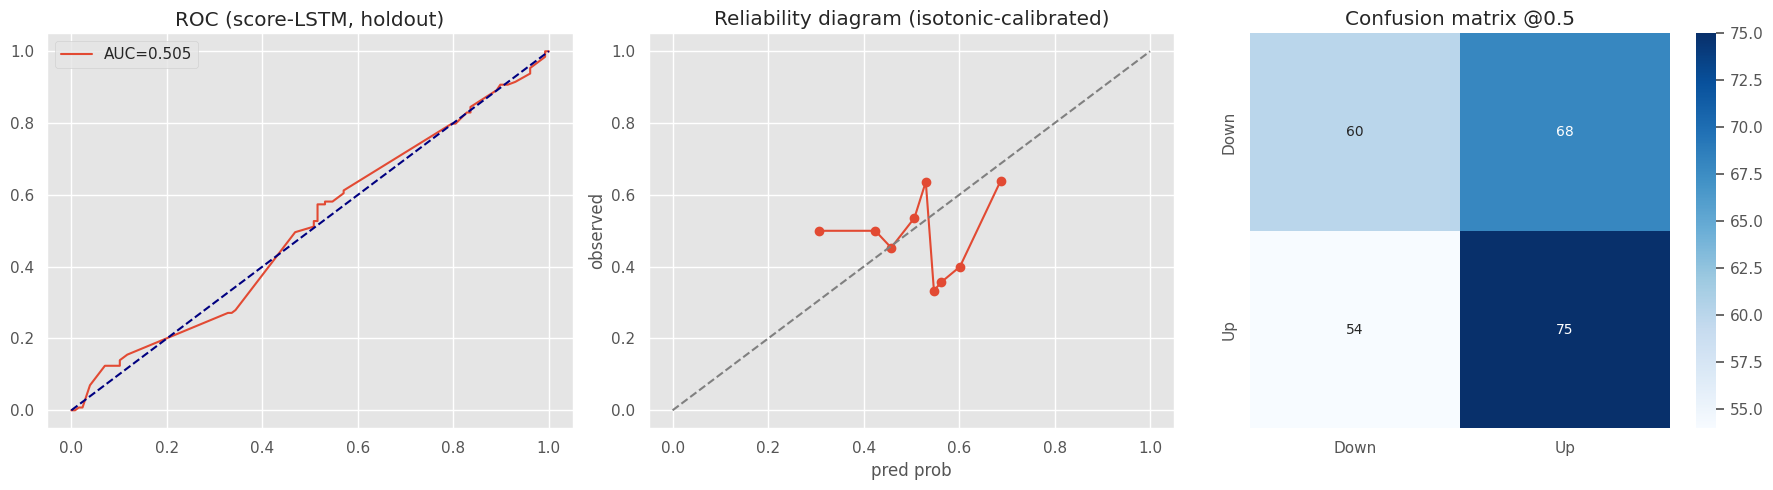

In [14]:
from sklearn.metrics import roc_curve, auc, confusion_matrix
from sklearn.calibration import calibration_curve

p, yv = proba_s.values, labels_s.values
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fpr, tpr, _ = roc_curve(yv, p); axes[0].plot(fpr, tpr, label=f"AUC={auc(fpr, tpr):.3f}")
axes[0].plot([0, 1], [0, 1], "--", c="navy"); axes[0].set_title("ROC (score-LSTM, holdout)"); axes[0].legend()
frac_pos, mean_pred = calibration_curve(yv, p, n_bins=10, strategy="quantile")
axes[1].plot(mean_pred, frac_pos, "o-"); axes[1].plot([0, 1], [0, 1], "--", c="gray")
axes[1].set_title("Reliability diagram (isotonic-calibrated)"); axes[1].set_xlabel("pred prob"); axes[1].set_ylabel("observed")
cm = confusion_matrix(yv, (p > 0.5).astype(int))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[2], xticklabels=["Down", "Up"], yticklabels=["Down", "Up"])
axes[2].set_title("Confusion matrix @0.5"); plt.tight_layout(); plt.show()


## 6b. Three tracks + post-cutoff buy overlay

Holdout metrics for **scores / embeddings / fused** LSTMs side by side, with the new
`calibration_kept` + `collapse_frac` diagnostics (calibration is now adopted only if it
improves dev-tail Brier; `collapse_frac`→1 means the model predicts ~one side and the
"tuned" metrics aren't real skill).

Then the **post-cutoff buy-only overlay** (operator spec): post-2023-10-07 days never
touch training — here the pre-cutoff model's held-out decisions are combined with a
**forced BUY** on every post-cutoff day, scored against the real next-day direction.

In [ ]:
# All three LSTM tracks on the sacred holdout + the post-cutoff buy overlay.
from sentisense.features import build_embedding_dataset, build_fused_dataset
from sentisense.hpo import postcutoff_buy_overlay
from sentisense.hpo.optuna_lstm import STUDY_EMB, STUDY_FUSED
from sentisense.config import EMBED_PCA_COMPONENTS

rows = {"scores": {k: v["mean"] for k, v in summary_s.items()}}

def _track(name, df, study_name, **kw):
    st = load_or_none(study_name)
    if st is None or df is None or df.empty:
        print(f"skip {name}: no completed study / no data"); return
    summ, _, _ = final_holdout_eval(df, st.best_params, n_seeds=2, **kw)
    rows[name] = {k: v["mean"] for k, v in summ.items()}

_track("embeddings", build_embedding_dataset(engine), STUDY_EMB,
       pca_components=EMBED_PCA_COMPONENTS, pca_prefix="embc_")
_track("fused", build_fused_dataset(engine), STUDY_FUSED,
       pca_components=EMBED_PCA_COMPONENTS, pca_prefix="embc_")

cols = ["roc_auc@tuned", "accuracy@tuned", "mcc@tuned", "brier_cal", "calibration_kept", "collapse_frac"]
comp = pd.DataFrame(rows).T
display(comp[[c for c in cols if c in comp.columns]])

# Post-cutoff buy-overlay (operator spec): pre-cutoff model decisions + forced BUY on
# every post-2023-10-07 trading day, combined confusion.
ov = postcutoff_buy_overlay(proba_s, labels_s, threshold=0.5)
cm2 = np.array([[ov["tn"], ov["fp"]], [ov["fn"], ov["tp"]]])
fig, ax = plt.subplots(figsize=(4, 4))
sns.heatmap(cm2, annot=True, fmt="d", cmap="Greens", ax=ax,
            xticklabels=["pred Down", "pred Up/BUY"], yticklabels=["real Down", "real Up"])
ax.set_title(f"Buy-overlay confusion — combined acc {ov['combined_accuracy']:.3f}"); plt.show()
print(f"pre-cutoff days={ov['n_pre']} (model) | post-cutoff days={ov['n_post']} (forced BUY) | "
      f"post buy-only acc {ov['postcutoff_buy_accuracy']:.3f}")


## 7. Backtest — equity curve, Sharpe, max drawdown
Long-when-predicted-up vs Buy&Hold on the sacred test window, using real TA-125 returns.
This is the "is it tradeable" view — directional accuracy != P&L.

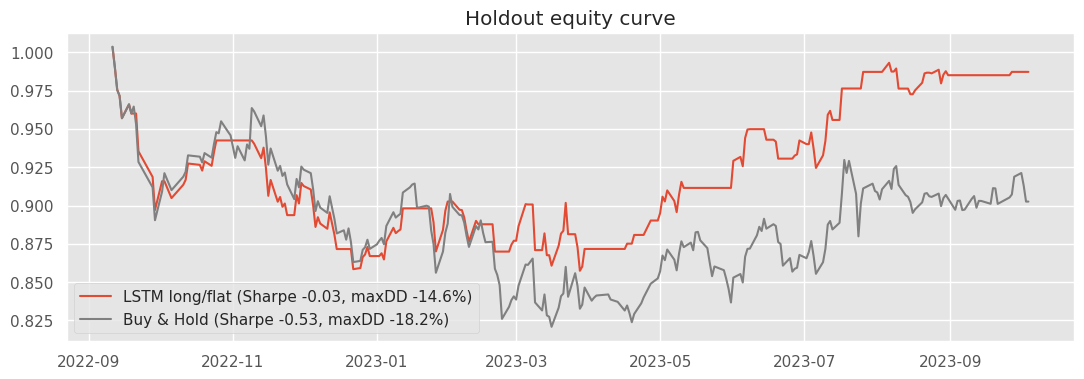

Strategy total return: -1.3% | Buy&Hold: -9.7%


In [15]:
from sentisense.constants import TA125_CSV
ta = pd.read_csv(TA125_CSV)
ta["Date"] = pd.to_datetime(ta["Date"], errors="coerce")
ta = ta.dropna(subset=["Date"]).set_index("Date").sort_index()
price = ta["Price"].astype(str).str.replace(",", "", regex=False).astype(float)
ret = price.pct_change()

dates = proba_s.index
nxt_ret = ret.reindex(dates).shift(-1).fillna(0.0)   # next-day return realised on the prediction
signal = (proba_s.values > 0.5).astype(float)        # long if up predicted, else flat
strat = signal * nxt_ret.values
bh = nxt_ret.values


def sharpe(r):
    r = np.asarray(r); return float(np.sqrt(252) * r.mean() / (r.std() + 1e-9))


def maxdd(eq):
    peak = np.maximum.accumulate(eq); return float(((eq - peak) / peak).min())


eq_s = np.cumprod(1 + strat); eq_bh = np.cumprod(1 + bh)
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(dates, eq_s, label=f"LSTM long/flat (Sharpe {sharpe(strat):.2f}, maxDD {maxdd(eq_s):.1%})")
ax.plot(dates, eq_bh, label=f"Buy & Hold (Sharpe {sharpe(bh):.2f}, maxDD {maxdd(eq_bh):.1%})", c="gray")
ax.set_title("Holdout equity curve"); ax.legend(); plt.show()
print(f"Strategy total return: {eq_s[-1] - 1:+.1%} | Buy&Hold: {eq_bh[-1] - 1:+.1%}")


## 8. Verdict — the honest read

**Latest run (3-seed holdout, tuned threshold):**

| track | ROC-AUC | acc | MCC | brier_cal |
|---|---|---|---|---|
| score-LSTM | 0.514 ±0.011 | 0.519 | 0.053 ±0.072 | 0.258 |
| embedding-LSTM | 0.505 ±0.017 | 0.522 | 0.012 ±0.072 | 0.269→fixed |
| random | 0.50 | ~0.51 | 0 | 0.25 |

- **No detectable edge.** AUC ≈ 0.51 on both tracks; MCC confidence intervals cross 0.
  Next-day TA-125 direction from daily Hebrew-news sentiment is ≈ efficient-market
  unpredictable. More HPO trials will **not** move 0.51 → 0.60 — the signal isn't there.
- **What was fixed this round** (don't fool ourselves): calibration is now adopted only
  when it improves the dev-tail Brier (the embedding model's `brier_cal 0.269 > raw 0.251`
  was isotonic over-fitting a tiny dev tail); a `collapse_frac` diagnostic exposes
  near-one-class prediction; the holdout logs a loud "no detectable edge" warning.
- **Fused track (§6b)** — scores ⊕ embeddings in one model. If even the fused view is
  ≈0.51, that's strong evidence the ceiling is the data/target, not the architecture.
- **Where signal lives (§4 SHAP-by-family)** — expect cross-asset/technical features to
  dominate news; that's the honest "does the news earn its place?" answer.
- **Tradeable? (§7)** Sharpe + max-drawdown vs Buy&Hold. Coin-flip direction → don't trade it.
- **Buy-overlay (§6b)** — post-2023-10-07 forced-BUY combined scorecard. This measures the
  post-war "just buy" stance, not model skill; read its accuracy as the real post-cutoff
  up-rate, kept separate from the (chance-level) model decisions.

**Where an edge might still exist** (reframe the target, not the tuner): multi-day horizon,
a magnitude threshold (predict only moves > X%), abstention (trade only high-confidence
days), or regime-conditioned models. Those are the next experiments worth running.